In [1]:
from src.db import PBWarehouse
import polars as pl
from src.models import Tweet
import seaborn as sns
import matplotlib.pyplot as plt
from src.config import MPL_STYLE_DIR

warehouse = PBWarehouse()

plt.style.use(MPL_STYLE_DIR / "iragca_ml.mplstyle")

2025-07-05 19:05:31.605 | INFO     | src.config:<module>:25 - Loaded environment variables from /home/iragca/Documents/github/capstone-project-2/.env
2025-07-05 19:05:31.606 | INFO     | src.config:<module>:58 - PROJECT_ROOT: /home/iragca/Documents/github/capstone-project-2
2025-07-05 19:05:31.606 | INFO     | src.config:<module>:59 - DATA_DIR: /home/iragca/Documents/github/capstone-project-2/data


In [2]:
data = warehouse.client.collection("tweets_v2").get_full_list()
tweets: list[Tweet] = [Tweet(**r.__dict__) for r in data]

In [3]:
df = pl.DataFrame(
    [t.model_dump() for t in tweets],
    schema={
        "tweet_id": pl.Utf8,
        "text": pl.Utf8,
        "status_link": pl.Utf8,
        "user_id": pl.Utf8,
        "extremist": pl.Boolean,
        "is_annotated": pl.Boolean,
        "bookmark_count": pl.Int64,
        "views": pl.Int64,
        "retweet_count": pl.Int64,
        "favorite_count": pl.Int64,
        "reply_count": pl.Int64,
        "quote_count": pl.Int64,
        "in_reply_to_status_id": pl.Utf8,
        "conversation_id": pl.Utf8,
        "retweet_tweet_id": pl.Utf8,
        "quoted_status_id": pl.Utf8,
        "community_note": pl.Utf8,
        "language": pl.Utf8,
        "source": pl.Utf8,
        "creation_date": pl.Utf8,
        "has_blm_hashtag": pl.Boolean,
        "fetched_replies": pl.Boolean,
        "is_reply_to_blm": pl.Boolean,
    },
).with_columns(
    pl.col("creation_date").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S%.3fZ")
)
df

tweet_id,text,status_link,user_id,extremist,is_annotated,bookmark_count,views,retweet_count,favorite_count,reply_count,quote_count,in_reply_to_status_id,conversation_id,retweet_tweet_id,quoted_status_id,community_note,language,source,creation_date,has_blm_hashtag,fetched_replies,is_reply_to_blm
str,str,str,str,bool,bool,i64,i64,i64,i64,i64,i64,str,str,str,str,str,str,str,datetime[ms],bool,bool,bool
"""1286447415080312833""","""Heyhey if you are someone/know…","""https://x.com/ChuckMockler/sta…","""347913343""",null,false,0,0,1,2,0,0,"""""","""1286447415080312833""","""""","""""","""""","""en""","""Twitter for iPhone""",2020-07-23 23:45:39,true,true,false
"""1286440938106163203""","""Thank you @VoteAdamMedrano for…","""https://x.com/AdamBazaldua/sta…","""833871911272722433""",null,false,0,0,4,16,4,1,"""""","""1286440938106163203""","""""","""""","""""","""en""","""Twitter for iPhone""",2020-07-23 23:19:55,true,true,false
"""1286450496329285632""","""I have ten-ish years of experi…","""https://x.com/LilyShumarKray/s…","""773036078""",null,false,0,0,0,3,0,0,"""1286450494349533184""","""1286450494349533184""","""""","""""","""""","""en""","""""",2020-07-23 23:57:54,false,true,true
"""1286449430095450117""","""@TJMufuta How about stop press…","""https://x.com/LushLife243/stat…","""115154507""",null,false,0,0,0,0,1,0,"""1286449058865917952""","""1286442752113283073""","""""","""""","""""","""en""","""""",2020-07-23 23:53:39,false,true,false
"""1550587195064557568""","""@BmbEmpower Yawn...""","""https://x.com/MrNice1000/statu…","""1484512765842706432""",null,false,0,0,0,0,0,0,"""1550579368648478721""","""1550579368648478721""","""""","""""","""""","""en""","""""",2022-07-22 21:02:50,false,true,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""1938755211964629088""","""If your defeat makes you horny…","""https://x.com/celebf_project/s…","""1479928558562779141""",null,false,10,1707,2,45,0,0,"""""","""1938755211964629088""","""""","""""","""""","""en""","""Twitter Web App""",2025-06-28 00:23:57,true,false,false
"""1939797148796686378""","""Politie start onderzoek naar o…","""https://x.com/NOS/status/19397…","""7174972""",null,false,7,0,33,372,158,9,"""""","""1939797148796686378""","""""","""""","""""","""nl""","""""",2025-06-30 21:24:14,false,false,false
"""1939995332701532413""","""Voor alle schizofrene, antisem…","""https://x.com/D62Darya/status/…","""517704272""",null,false,1,778,1,17,1,1,"""""","""1939995332701532413""","""""","""1939797148796686378""","""""","""en""","""Twitter Web App""",2025-07-01 10:31:45,true,false,false


In [4]:
sorted_df = df.sort(pl.col("creation_date")).group_by_dynamic("creation_date", every="1mo").agg(
    [
        pl.col("tweet_id").count().alias("total_tweets"),
    ])

<Axes: xlabel='creation_date', ylabel='total_tweets'>

findfont: Generic family 'sans-serif' not found because none of the following families were found: Roboto, Helvetica, Arial, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Roboto, Helvetica, Arial, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Roboto, Helvetica, Arial, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Roboto, Helvetica, Arial, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Roboto, Helvetica, Arial, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Roboto, Helvetica, Arial, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Roboto, Helvetica, Arial, sans-serif
findfont: Generic family 'sans-serif' not found 

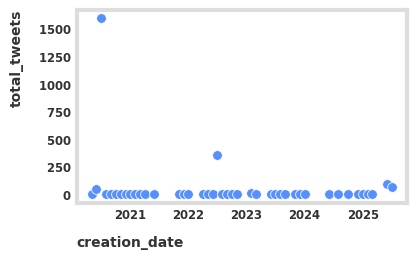

In [5]:
sns.scatterplot(
    data=sorted_df.to_pandas(),
    x="creation_date",
    y="total_tweets",
    marker="o")